# Figure 1 and Supplementary Figure S1


## Setup and calculations


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, zoom
plt.rcParams.update({'figure.figsize': (6.8, 4.2), 'figure.dpi': 300, 'savefig.dpi': 300, 'font.size': 6, 'axes.titlesize': 6, 'axes.labelsize': 6, 'legend.fontsize': 6, 'legend.title_fontsize': 6, 'figure.titlesize': 6, 'figure.labelsize': 6, 'xtick.labelsize': 4, 'ytick.labelsize': 4})
import anndata as ad
from sklearn.isotonic import IsotonicRegression
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / 'epsbasin').is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
import epsbasin
import epsbasin.shortest_path as shortest_path_module
print('epsbasin.shortest_path loaded from:', shortest_path_module.__file__)
assert hasattr(shortest_path_module, 'minimum_epsilon_and_paths_to_good_bad'), 'The loaded epsbasin/shortest_path.py does not contain minimum_epsilon_and_paths_to_good_bad. Replace it with the path-enabled shortest_path.py supplied with this notebook.'
from epsbasin.shortest_path import build_terminal_state_graph, eps_attracting_basin_shortest_path, eps_sum_attracting_basin_shortest_path, minimum_epsilon_to_good_bad, minimum_epsilon_and_paths_to_good_bad
OUTPUT_DIR = Path('figure_source/Simple')
SAVE_FIGURES = True

class PlotStyle:
    seed: int = 0
    dpi: int = 300
    save_dpi: int = 600
    title_fs: int = 8
    title_pad: float = 4
    label_fs: int = 8
    tick_fs: int = 6
    tick_length: float = 2
    tick_lw: float = 0.5
    tick_pad: float = 1
    good_color: str = '#b1182b'
    bad_color: str = '#2166ac'
    good2_color: str = 'tab:orange'
STYLE = PlotStyle()
DISPLAY_SMOOTH_SIGMA = 2.0
DISPLAY_UPSAMPLE = 4
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, file_name, *, png=True, svg=True):
    if not SAVE_FIGURES:
        return []
    paths = []
    if png:
        path = OUTPUT_DIR / f'{file_name}.png'
        fig.savefig(path, dpi=STYLE.dpi, bbox_inches='tight', format='png')
        paths.append(path)
    if svg:
        path = OUTPUT_DIR / f'{file_name}.svg'
        fig.savefig(path, dpi=STYLE.dpi, bbox_inches='tight', format='svg')
        paths.append(path)
    print('Saved:', ', '.join(map(str, paths)))
    return paths

def _finite_minmax(values, default=(0.0, 1.0)):
    arr = np.asarray(values, dtype=float)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return tuple((float(v) for v in default))
    return (float(np.min(finite)), float(np.max(finite)))

def _plot_safe_array(values, *, lower=None, upper=None, default=0.0):
    """Return a plotting-only copy containing no +/-inf.

    +inf and -inf are clipped to the requested display limits (or to the
    finite data range). NaNs are masked. The original scientific values are
    never modified.
    """
    arr = np.asarray(values, dtype=float).copy()
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        lo = float(default if lower is None else lower)
        hi = float(default if upper is None else upper)
    else:
        lo = float(np.min(finite) if lower is None else lower)
        hi = float(np.max(finite) if upper is None else upper)
    if not np.isfinite(lo):
        lo = float(default)
    if not np.isfinite(hi):
        hi = float(default)
    if hi < lo:
        lo, hi = (hi, lo)
    if np.isclose(lo, hi):
        pad = max(1e-12, 0.05 * max(1.0, abs(lo)))
        lo -= pad
        hi += pad
    arr[np.isneginf(arr)] = lo
    arr[np.isposinf(arr)] = hi
    return np.ma.masked_invalid(arr)

def _smooth_regular_grid_for_display(X_grid, Y_grid, values, *, sigma=DISPLAY_SMOOTH_SIGMA, upsample=DISPLAY_UPSAMPLE, lower=None, upper=None):
    """Return a smooth, dense plotting copy of a regular-grid field.

    The stored field is left untouched.  Gaussian filtering is normalized by
    a finite-value weight field, so NaNs do not bleed into valid regions.
    Cubic upsampling then removes visible contour facets in schematic panels.
    Set ``sigma=0`` and ``upsample=1`` to display the unsmoothed grid.
    """
    X_grid = np.asarray(X_grid, dtype=float)
    Y_grid = np.asarray(Y_grid, dtype=float)
    if X_grid.shape != Y_grid.shape:
        raise ValueError('X_grid and Y_grid must have the same shape.')
    plot_values = _plot_safe_array(values, lower=lower, upper=upper).filled(np.nan)
    if plot_values.shape != X_grid.shape:
        raise ValueError('values must have the same shape as the plotting grid.')
    sigma = float(sigma)
    upsample_float = float(upsample)
    upsample = int(upsample_float)
    if sigma < 0.0:
        raise ValueError('sigma must be nonnegative.')
    if upsample < 1 or not np.isclose(upsample_float, upsample):
        raise ValueError('upsample must be a positive integer.')
    finite = np.isfinite(plot_values)
    if not np.any(finite):
        raise ValueError('The display field contains no finite values.')
    display_lower = float(np.nanmin(plot_values)) if lower is None else float(lower)
    display_upper = float(np.nanmax(plot_values)) if upper is None else float(upper)
    if sigma > 0.0:
        numerator = gaussian_filter(np.where(finite, plot_values, 0.0), sigma=sigma, mode='nearest')
        denominator = gaussian_filter(finite.astype(float), sigma=sigma, mode='nearest')
        smoothed = np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator > 1e-10)
    else:
        smoothed = plot_values.copy()
    if upsample > 1:
        smoothed = zoom(smoothed, (upsample, upsample), order=3, mode='nearest', prefilter=True)
        support = zoom(finite.astype(float), (upsample, upsample), order=1, mode='nearest', prefilter=False)
        smoothed[support <= 1e-06] = np.nan
    finite_smoothed = np.isfinite(smoothed)
    smoothed[finite_smoothed] = np.clip(smoothed[finite_smoothed], display_lower, display_upper)
    x_dense = np.linspace(float(X_grid[0, 0]), float(X_grid[0, -1]), smoothed.shape[1])
    y_dense = np.linspace(float(Y_grid[0, 0]), float(Y_grid[-1, 0]), smoothed.shape[0])
    X_dense, Y_dense = np.meshgrid(x_dense, y_dense)
    return (X_dense, Y_dense, smoothed)

def _extended_close(a, b, *, atol=1e-10):
    """Compare finite values and same-signed infinities safely."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    same_pos = np.isposinf(a) & np.isposinf(b)
    same_neg = np.isneginf(a) & np.isneginf(b)
    finite = np.isfinite(a) & np.isfinite(b)
    ok = same_pos | same_neg
    ok = ok | finite & np.isclose(a, b, atol=atol, rtol=0.0)
    return bool(np.all(ok))


epsbasin.shortest_path loaded from: /home/dell2023/GitHub/eps-attracting-basin/epsbasin/shortest_path.py


/home/dell2023/GitHub/eps-attracting-basin/epsbasin/epsbasin.py:217: SyntaxWarning: invalid escape sequence '\S'
  """
/home/dell2023/GitHub/eps-attracting-basin/epsbasin/epsbasin.py:347: SyntaxWarning: invalid escape sequence '\S'
  """


In [2]:
def hill_function(x, hill_coef=5, hill_half=2.0):
    x = np.asarray(x, dtype=float)
    return x ** hill_coef / (hill_half ** hill_coef + x ** hill_coef)

def uniform_disk_noise(n, scale, rng):
    radius = scale * np.sqrt(rng.uniform(size=n))
    angle = rng.uniform(0.0, 2.0 * np.pi, size=n)
    return np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])
xlim = [0.0, 2.0]
xdiv = 20
scale = 5.0
hill_coef = 5
hill_half = 2.0
I = 20
noise_scale = 0.1
random_state = 0
rng = np.random.default_rng(random_state)
x = np.linspace(xlim[0], xlim[1], xdiv)
y = hill_function(x, hill_coef=hill_coef, hill_half=hill_half)
base_top = np.column_stack([x, y])
base_bottom = np.column_stack([x, -y])
sequences = []
seq_ids = []
time_indices = []
branch_labels = []
seq_id = 0
for branch_name, base in [('top', base_top), ('bottom', base_bottom)]:
    for _ in range(I):
        seq = base + uniform_disk_noise(xdiv, noise_scale, rng)
        sequences.append(scale * seq)
        seq_ids.extend([seq_id] * xdiv)
        time_indices.extend(range(xdiv))
        branch_labels.extend([branch_name] * xdiv)
        seq_id += 1
data_2d_flat = np.vstack(sequences)
seq_ids = np.asarray(seq_ids, dtype=int)
time_indices = np.asarray(time_indices, dtype=int)
branch_labels = np.asarray(branch_labels, dtype=object)
EX_CLUSTER_KEY = 'good'
NE_CLUSTER_KEY = 'bad'
cluster = np.full(data_2d_flat.shape[0], 'others', dtype=object)
outcome = np.full(data_2d_flat.shape[0], 'others', dtype=object)
for sid in np.unique(seq_ids):
    idx = np.flatnonzero(seq_ids == sid)
    terminal = idx[np.argmax(time_indices[idx])]
    if data_2d_flat[terminal, 1] > 0:
        cluster[terminal] = EX_CLUSTER_KEY
        outcome[terminal] = 'EX'
    else:
        cluster[terminal] = NE_CLUSTER_KEY
        outcome[terminal] = 'NE'
adata = ad.AnnData(X=data_2d_flat)
adata.obs = pd.DataFrame({'seq_id': seq_ids, 'time_idx': time_indices, 'cluster': cluster, 'outcome': outcome, 'branch': branch_labels, 'x': data_2d_flat[:, 0], 'y': data_2d_flat[:, 1]}, index=adata.obs_names.copy())
adata


AnnData object with n_obs × n_vars = 800 × 2
    obs: 'seq_id', 'time_idx', 'cluster', 'outcome', 'branch', 'x', 'y'

In [3]:
def infer_query_times_from_nearest_ensemble(adata_obj, query_points, *, time_key='time_idx', chunk_size=2048, tie_atol=1e-12, return_details=False):
    """Assign each query the time of its nearest ensemble observation.

    Euclidean distance is evaluated in the complete state space.  Ties within
    ``tie_atol`` are resolved by the earliest time and then the smallest
    observation index, giving a deterministic assignment even if the AnnData
    rows are not grouped by time.
    """
    X = np.asarray(adata_obj.X, dtype=float)
    points = np.asarray(query_points, dtype=float)
    if points.ndim == 1:
        points = points[None, :]
    if X.ndim != 2 or points.ndim != 2:
        raise ValueError('Ensemble states and query_points must be 2D arrays.')
    if points.shape[1] != X.shape[1]:
        raise ValueError(f'State dimension mismatch: queries have {points.shape[1]} coordinates but ensemble states have {X.shape[1]}.')
    if X.shape[0] == 0:
        raise ValueError('The ensemble contains no observations.')
    if not np.all(np.isfinite(X)) or not np.all(np.isfinite(points)):
        raise ValueError('Ensemble states and query points must be finite.')
    if int(chunk_size) <= 0:
        raise ValueError('chunk_size must be a positive integer.')
    if float(tie_atol) < 0.0:
        raise ValueError('tie_atol must be nonnegative.')
    time_values = adata_obj.obs[time_key].to_numpy(dtype=int)
    if time_values.shape[0] != X.shape[0]:
        raise ValueError('time_idx length does not match the ensemble size.')
    inferred_times = np.empty(points.shape[0], dtype=int)
    nearest_indices = np.empty(points.shape[0], dtype=int)
    nearest_distances = np.empty(points.shape[0], dtype=float)
    sentinel_time = int(np.max(time_values)) + 1
    for start in range(0, points.shape[0], int(chunk_size)):
        stop = min(start + int(chunk_size), points.shape[0])
        delta = points[start:stop, None, :] - X[None, :, :]
        distances = np.linalg.norm(delta, axis=2)
        minimum = np.min(distances, axis=1)
        tied = np.isclose(distances, minimum[:, None], rtol=0.0, atol=float(tie_atol))
        earliest_times = np.min(np.where(tied, time_values[None, :], sentinel_time), axis=1)
        eligible = tied & (time_values[None, :] == earliest_times[:, None])
        selected = np.argmax(eligible, axis=1)
        inferred_times[start:stop] = earliest_times
        nearest_indices[start:stop] = selected
        nearest_distances[start:stop] = distances[np.arange(stop - start), selected]
    if return_details:
        return (inferred_times, nearest_indices, nearest_distances)
    return inferred_times

def infer_query_time_from_nearest_ensemble(adata_obj, query_point, *, time_key='time_idx', tie_atol=1e-12, return_details=False):
    """Scalar wrapper for nearest-ensemble query-time assignment."""
    point = np.asarray(query_point, dtype=float).reshape(-1)
    times, indices, distances = infer_query_times_from_nearest_ensemble(adata_obj, point[None, :], time_key=time_key, tie_atol=tie_atol, return_details=True)
    if return_details:
        return (int(times[0]), int(indices[0]), float(distances[0]))
    return int(times[0])
NEAREST_TIME_REFERENCE_COUNTS = adata.obs.groupby('time_idx', observed=True).size().rename('n_ensemble_points').reset_index()
display(NEAREST_TIME_REFERENCE_COUNTS)


,time_idx,n_ensemble_points
0,0,40
1,1,40
2,2,40
3,3,40
4,4,40
5,5,40
6,6,40
7,7,40
8,8,40
9,9,40


In [4]:
eps_attracting_basin_shortest_path(adata, seq_key='seq_id', time_key='time_idx', cluster_key='cluster', good_cluster_key='good', bad_cluster_key='bad', cost_matrix_key='cost_matrix', sequence_edge_mode='adjacent', transition_mode='time_layered', output_key='eps_attracting_basin_sp', distance_key='eps_distance_sp', terminal_class_key='terminal_class', store_next_hop=True)
adata.obs[['cluster', 'time_idx', 'terminal_class', 'eps_attracting_basin_sp_good', 'eps_attracting_basin_sp_bad', 'eps_attracting_basin_sp_landscape']].head()


,cluster,time_idx,terminal_class,eps_attracting_basin_sp_good,eps_attracting_basin_sp_bad,eps_attracting_basin_sp_landscape
0,others,0,good,-0.043361,0.043361,-0.043361
1,others,1,good,-0.043361,0.043361,-0.043361
2,others,2,good,-0.043361,0.043361,-0.043361
3,others,3,good,-0.043361,0.043361,-0.043361
4,others,4,good,-0.043361,0.043361,-0.043361


In [5]:
eps_sum_attracting_basin_shortest_path(adata, seq_key='seq_id', time_key='time_idx', cluster_key='cluster', good_cluster_key='good', bad_cluster_key='bad', cost_matrix_key='cost_matrix', sequence_edge_mode='adjacent', transition_mode='time_layered', output_key='eps_sum_attracting_basin_sp', distance_key='eps_sum_distance_sp')
adata.obs[['cluster', 'time_idx', 'eps_sum_attracting_basin_sp_good', 'eps_sum_attracting_basin_sp_bad', 'eps_sum_attracting_basin_sp_landscape']].head()


,cluster,time_idx,eps_sum_attracting_basin_sp_good,eps_sum_attracting_basin_sp_bad,eps_sum_attracting_basin_sp_landscape
0,others,0,-0.043361,0.043361,-0.043361
1,others,1,-0.043361,0.043361,-0.043361
2,others,2,-0.043361,0.043361,-0.043361
3,others,3,-0.043361,0.043361,-0.043361
4,others,4,-0.043361,0.043361,-0.043361


In [6]:
PLAN_DEMO_SEQ_ID = 38
PLAN_DEMO_SOURCE_TIME_IDX = 4
seq_values_demo = adata.obs['seq_id'].to_numpy(dtype=int)
time_values_demo = adata.obs['time_idx'].to_numpy(dtype=int)
query_obs = np.flatnonzero((seq_values_demo == PLAN_DEMO_SEQ_ID) & (time_values_demo == PLAN_DEMO_SOURCE_TIME_IDX))
if query_obs.size != 1:
    raise RuntimeError('Could not identify the requested demonstration state uniquely.')
PLAN_DEMO_OBS_INDEX = int(query_obs[0])
x_plan_demo = np.asarray(adata.X[PLAN_DEMO_OBS_INDEX], dtype=float).copy() + [0.01, -0.01]
PLAN_DEMO_QUERY_TIME_IDX, PLAN_DEMO_NEAREST_OBS_INDEX, PLAN_DEMO_NEAREST_DISTANCE = infer_query_time_from_nearest_ensemble(adata, x_plan_demo, return_details=True)
plan_demo_query_costs = np.full(adata.n_obs, np.inf, dtype=float)
mask_plan_time = time_values_demo == PLAN_DEMO_QUERY_TIME_IDX
plan_demo_query_costs[mask_plan_time] = np.linalg.norm(np.asarray(adata.X[mask_plan_time], dtype=float) - x_plan_demo[None, :], axis=1)
plan_demo_inf = minimum_epsilon_and_paths_to_good_bad(adata, x_plan_demo, plan_demo_query_costs, output_key='eps_attracting_basin_sp', time_value=PLAN_DEMO_QUERY_TIME_IDX)
plan_demo_one = minimum_epsilon_and_paths_to_good_bad(adata, x_plan_demo, plan_demo_query_costs, output_key='eps_sum_attracting_basin_sp', time_value=PLAN_DEMO_QUERY_TIME_IDX)

def nonzero_control_steps(path, tol=1e-10):
    return [step for step in path.steps if step.kind in {'entry', 'switch', 'graph'} and float(step.cost) > tol]

def control_step_table(path, adata_obj):
    rows = []
    control_no = 0
    for step in path.steps:
        if step.kind not in {'entry', 'switch', 'graph'}:
            continue
        if float(step.cost) <= 1e-10:
            continue
        control_no += 1
        if step.source_index is None:
            source_seq = 'query x'
            source_time = PLAN_DEMO_QUERY_TIME_IDX
        else:
            source_seq = int(adata_obj.obs.iloc[int(step.source_index)]['seq_id'])
            source_time = int(adata_obj.obs.iloc[int(step.source_index)]['time_idx'])
        destination = int(step.destination_index)
        rows.append({'control': control_no, 'kind': step.kind, 'time_idx': source_time, 'source_seq': source_seq, 'destination_seq': int(adata_obj.obs.iloc[destination]['seq_id']), 'epsilon_i': float(step.cost)})
    return pd.DataFrame(rows)
controls_one_steps = nonzero_control_steps(plan_demo_one.path_good)
controls_inf_steps = nonzero_control_steps(plan_demo_inf.path_good)
controls_one = [float(step.cost) for step in controls_one_steps]
controls_inf = [float(step.cost) for step in controls_inf_steps]
plan_demo_summary = pd.DataFrame([{'p': '1', 'C_p,EX': float(plan_demo_one.epsilon_good), 'n_nonzero_controls': len(controls_one), 'control_amplitudes': np.round(controls_one, 5).tolist(), 'sum_epsilon': float(np.sum(controls_one)), 'max_epsilon': float(np.max(controls_one))}, {'p': 'infinity', 'C_p,EX': float(plan_demo_inf.epsilon_good), 'n_nonzero_controls': len(controls_inf), 'control_amplitudes': np.round(controls_inf, 5).tolist(), 'sum_epsilon': float(np.sum(controls_inf)), 'max_epsilon': float(np.max(controls_inf))}])
print(f'Query taken from the original ensemble: seq_id={PLAN_DEMO_SEQ_ID}, source_time_idx={PLAN_DEMO_SOURCE_TIME_IDX}, nearest_obs_index={PLAN_DEMO_NEAREST_OBS_INDEX}, nearest_distance={PLAN_DEMO_NEAREST_DISTANCE:.4g}, inferred_query_time_idx={PLAN_DEMO_QUERY_TIME_IDX}, x={np.round(x_plan_demo, 4)}')
display(plan_demo_summary)
print('p=1 controls toward EX')
display(control_step_table(plan_demo_one.path_good, adata))
print('p=infinity controls toward EX')
display(control_step_table(plan_demo_inf.path_good, adata))
print('\nInterpretation')
print(f'  p=1        : smaller total perturbation -> one larger switch (sum={np.sum(controls_one):.4f})')
print(f'  p=infinity : smaller worst-case perturbation -> relay of smaller switches (max={np.max(controls_inf):.4f})')


Query taken from the original ensemble: seq_id=38, source_time_idx=4, nearest_obs_index=764, nearest_distance=0.01414, inferred_query_time_idx=4, x=[ 2.3764 -0.4335]


,p,"C_p,EX",n_nonzero_controls,control_amplitudes,sum_epsilon,max_epsilon
0,1,0.073177,2,"[0.01414, 0.05903]",0.073177,0.059035
1,infinity,0.030510,3,"[0.03051, 0.0234, 0.02403]",0.077937,0.030510


p=1 controls toward EX


,control,kind,time_idx,source_seq,destination_seq,epsilon_i
0,1,entry,4,query x,38,0.014142
1,2,switch,5,38,13,0.059035


p=infinity controls toward EX


,control,kind,time_idx,source_seq,destination_seq,epsilon_i
0,1,entry,4,query x,34,0.030510
1,2,switch,7,34,26,0.023397
2,3,switch,10,26,14,0.024030



Interpretation
  p=1        : smaller total perturbation -> one larger switch (sum=0.0732)
  p=infinity : smaller worst-case perturbation -> relay of smaller switches (max=0.0305)


In [7]:
def evaluate_external_state(adata_train, x, costs, *, output_key, time_value):
    """Evaluate a held-out/background state using the time-layered package helper."""
    return minimum_epsilon_to_good_bad(adata_train, x, costs, output_key=output_key, time_value=time_value)


In [8]:
def leave_one_sequence_out_cv(adata_full, *, path_cost='max', seq_key='seq_id', time_key='time_idx', cluster_key='cluster', good_cluster_key='good', bad_cluster_key='bad', cost_matrix_key='cost_matrix', tie_tol=1e-12, verbose=True):
    """LOSO-CV with strict same-time entry and time-layered dynamics."""
    if path_cost not in {'max', 'sum'}:
        raise ValueError("path_cost must be 'max' or 'sum'.")
    seq_values = adata_full.obs[seq_key].to_numpy()
    time_values = adata_full.obs[time_key].to_numpy()
    all_indices = np.arange(adata_full.n_obs)
    seq_ids_unique = list(pd.unique(seq_values))
    if cost_matrix_key in adata_full.uns:
        full_cost = np.asarray(adata_full.uns[cost_matrix_key], dtype=float)
    else:
        from sklearn.metrics import pairwise_distances
        full_cost = pairwise_distances(adata_full.X)
    if full_cost.shape != (adata_full.n_obs, adata_full.n_obs):
        raise ValueError('The full cost matrix has an incompatible shape.')
    rows = []
    for fold, heldout_seq in enumerate(seq_ids_unique, start=1):
        test_indices = all_indices[seq_values == heldout_seq]
        test_indices = test_indices[np.argsort(time_values[test_indices])]
        train_indices = all_indices[seq_values != heldout_seq]
        adata_train = adata_full[train_indices].copy()
        adata_train.uns[cost_matrix_key] = full_cost[np.ix_(train_indices, train_indices)].copy()
        if path_cost == 'max':
            output_key = 'cv_eps_attracting_basin_sp'
            eps_attracting_basin_shortest_path(adata_train, seq_key=seq_key, time_key=time_key, cluster_key=cluster_key, good_cluster_key=good_cluster_key, bad_cluster_key=bad_cluster_key, cost_matrix_key=cost_matrix_key, sequence_edge_mode='adjacent', transition_mode='time_layered', output_key=output_key)
        else:
            output_key = 'cv_eps_sum_attracting_basin_sp'
            eps_sum_attracting_basin_shortest_path(adata_train, seq_key=seq_key, time_key=time_key, cluster_key=cluster_key, good_cluster_key=good_cluster_key, bad_cluster_key=bad_cluster_key, cost_matrix_key=cost_matrix_key, sequence_edge_mode='adjacent', transition_mode='time_layered', output_key=output_key)
        true_label = str(adata_full.obs.iloc[test_indices[-1]][cluster_key])
        if true_label not in {good_cluster_key, bad_cluster_key}:
            raise ValueError(f'Held-out sequence {heldout_seq!r} does not terminate in {good_cluster_key!r} or {bad_cluster_key!r}.')
        train_time_values = adata_train.obs[time_key].to_numpy()
        final_time_value = np.max(train_time_values)
        for step, global_index in enumerate(test_indices):
            time_value = time_values[global_index]
            x_query = np.asarray(adata_full.X[global_index], dtype=float).reshape(-1)
            costs_x_to_train = np.asarray(full_cost[global_index, train_indices], dtype=float).copy()
            costs_x_to_train[train_time_values != time_value] = np.inf
            if time_value == final_time_value:
                continue
            result = evaluate_external_state(adata_train, x_query, costs_x_to_train, output_key=output_key, time_value=time_value)
            score_good = result.epsilon_bad - result.epsilon_good
            if score_good > tie_tol:
                prediction = good_cluster_key
            elif score_good < -tie_tol:
                prediction = bad_cluster_key
            else:
                prediction = 'tie'
            entry_good_local = result.entry_index_good
            entry_bad_local = result.entry_index_bad
            entry_good_global = -1 if entry_good_local < 0 else int(train_indices[entry_good_local])
            entry_bad_global = -1 if entry_bad_local < 0 else int(train_indices[entry_bad_local])
            true_outcome = 'EX' if true_label == good_cluster_key else 'NE'
            if prediction == good_cluster_key:
                prediction_outcome = 'EX'
            elif prediction == bad_cluster_key:
                prediction_outcome = 'NE'
            else:
                prediction_outcome = 'tie'
            prediction_binary = 'EX' if score_good > 0.0 else 'NE'
            rows.append({'path_cost': path_cost, 'seq_id': heldout_seq, 'step': step, 'time_idx': time_value, 'fraction': 0.0 if len(test_indices) == 1 else step / (len(test_indices) - 1), 'global_index': int(global_index), 'x': float(adata_full.X[global_index, 0]), 'y': float(adata_full.X[global_index, 1]), 'true_outcome': true_outcome, 'C_EX': float(result.epsilon_good), 'C_NE': float(result.epsilon_bad), 'S_p': float(score_good), 'prediction_outcome': prediction_outcome, 'prediction_binary': prediction_binary, 'correct_outcome': prediction_outcome == true_outcome, 'correct_binary': prediction_binary == true_outcome, 'true_label': true_label, 'epsilon_good': result.epsilon_good, 'epsilon_bad': result.epsilon_bad, 'margin_good': score_good, 'prediction': prediction, 'correct': prediction == true_label, 'entry_good_global_index': entry_good_global, 'entry_bad_global_index': entry_bad_global})
        if verbose:
            print(f'[{fold:02d}/{len(seq_ids_unique):02d}] held out seq_id={heldout_seq!r}')
    return pd.DataFrame(rows)


In [9]:
cv_eps = leave_one_sequence_out_cv(adata, path_cost='max', seq_key='seq_id', time_key='time_idx', cluster_key='cluster', good_cluster_key='good', bad_cluster_key='bad', cost_matrix_key='cost_matrix', verbose=True)
cv_eps.head(10)


[01/40] held out seq_id=np.int64(0)
[02/40] held out seq_id=np.int64(1)
[03/40] held out seq_id=np.int64(2)
[04/40] held out seq_id=np.int64(3)
[05/40] held out seq_id=np.int64(4)
[06/40] held out seq_id=np.int64(5)
[07/40] held out seq_id=np.int64(6)
[08/40] held out seq_id=np.int64(7)
[09/40] held out seq_id=np.int64(8)
[10/40] held out seq_id=np.int64(9)
[11/40] held out seq_id=np.int64(10)
[12/40] held out seq_id=np.int64(11)
[13/40] held out seq_id=np.int64(12)
[14/40] held out seq_id=np.int64(13)
[15/40] held out seq_id=np.int64(14)
[16/40] held out seq_id=np.int64(15)
[17/40] held out seq_id=np.int64(16)
[18/40] held out seq_id=np.int64(17)
[19/40] held out seq_id=np.int64(18)
[20/40] held out seq_id=np.int64(19)
[21/40] held out seq_id=np.int64(20)
[22/40] held out seq_id=np.int64(21)
[23/40] held out seq_id=np.int64(22)
[24/40] held out seq_id=np.int64(23)
[25/40] held out seq_id=np.int64(24)
[26/40] held out seq_id=np.int64(25)
[27/40] held out seq_id=np.int64(26)
[28/40] hel

,path_cost,seq_id,step,time_idx,fraction,global_index,x,y,true_outcome,C_EX,...,correct_outcome,correct_binary,true_label,epsilon_good,epsilon_bad,margin_good,prediction,correct,entry_good_global_index,entry_bad_global_index
0,max,0,0,0,0.000000,0,0.392749,0.070632,EX,0.045768,...,True,True,good,0.045768,0.048356,0.002588,good,True,160,160
1,max,0,1,1,0.052632,1,0.710780,0.182812,EX,0.043444,...,False,False,good,0.043444,0.043444,0.000000,tie,False,101,101
2,max,0,2,2,0.105263,2,1.004222,-0.088817,EX,0.059007,...,False,False,good,0.059007,0.059007,0.000000,tie,False,782,782
3,max,0,3,3,0.157895,3,1.540252,-0.050838,EX,0.021054,...,True,True,good,0.021054,0.047629,0.026575,good,True,263,263
4,max,0,4,4,0.210526,4,1.767755,-0.296941,EX,0.035485,...,True,True,good,0.035485,0.051179,0.015694,good,True,164,164
5,max,0,5,5,0.263158,5,2.275895,0.325172,EX,0.035352,...,True,True,good,0.035352,0.043361,0.008009,good,True,385,505
6,max,0,6,6,0.315789,6,3.547269,0.008826,EX,0.146134,...,False,False,good,0.146134,0.146134,0.000000,tie,False,546,546
7,max,0,7,7,0.368421,7,4.108171,-0.017590,EX,0.104761,...,False,False,good,0.104761,0.104761,0.000000,tie,False,27,27
8,max,0,8,8,0.421053,8,4.065269,-0.273527,EX,0.030749,...,True,True,good,0.030749,0.073283,0.042534,good,True,108,588
9,max,0,9,9,0.473684,9,4.453780,-0.275514,EX,0.121955,...,False,False,good,0.121955,0.070527,-0.051428,bad,False,209,509


In [10]:
from mpl_toolkits.mplot3d import Axes3D
SURFACE_TIME_IDX = None
SURFACE_NX = 101
SURFACE_NY = 101
SAVE_SCORE_SURFACE_FIGURES = False
SCORE_SURFACE_OUTPUT_DIR = Path('figure_source')
if SAVE_SCORE_SURFACE_FIGURES:
    SCORE_SURFACE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _finite_symmetric_limit(values):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return 1.0
    value = float(np.max(np.abs(finite)))
    return 1.0 if value == 0.0 else value

def _time_layer_indices(adata_obj, time_value):
    seq_values = adata_obj.obs['seq_id'].to_numpy()
    time_values = adata_obj.obs['time_idx'].to_numpy()
    seq_ids_here = list(pd.unique(seq_values))
    unique_times = np.sort(pd.unique(time_values))
    matches = np.flatnonzero(unique_times == time_value)
    if matches.size != 1:
        raise ValueError(f'time_idx={time_value!r} is not in the data.')
    t_pos = int(matches[0])
    current = []
    following = []
    for sid in seq_ids_here:
        idx = np.flatnonzero(seq_values == sid)
        idx = idx[np.argsort(time_values[idx])]
        current_match = idx[time_values[idx] == time_value]
        if current_match.size != 1:
            raise ValueError(f'seq_id={sid!r} has {current_match.size} states at time {time_value}.')
        current.append(int(current_match[0]))
        if t_pos < unique_times.size - 1:
            next_time = unique_times[t_pos + 1]
            next_match = idx[time_values[idx] == next_time]
            if next_match.size != 1:
                raise ValueError(f'seq_id={sid!r} has {next_match.size} states at time {next_time}.')
            following.append(int(next_match[0]))
    return (np.asarray(current, dtype=int), None if not following else np.asarray(following, dtype=int), unique_times)

def _combine_entry_and_future(entry, future, path_cost):
    if path_cost == 'max':
        return np.min(np.maximum(entry, future[None, :]), axis=1)
    if path_cost == 'sum':
        return np.min(entry + future[None, :], axis=1)
    raise ValueError("path_cost must be 'max' or 'sum'.")

def compute_nearest_time_score_surface(adata_obj, *, distance_good_key, distance_bad_key, path_cost, score_label, nx=SURFACE_NX, ny=SURFACE_NY, pad_x=0.5, pad_y=0.5, good_cluster_key=EX_CLUSTER_KEY, bad_cluster_key=NE_CLUSTER_KEY):
    """Construct C-hat and S-hat using nearest-ensemble query times.

    For nonterminal time t, entry is made to an ensemble state at t and the
    stored continuation cost is read at t+1, matching the time-layered query
    recursion.  At the terminal time, entry is evaluated directly against the
    terminal target states.
    """
    if path_cost not in {'max', 'sum'}:
        raise ValueError("path_cost must be 'max' or 'sum'.")
    X = np.asarray(adata_obj.X, dtype=float)
    x_grid = np.linspace(X[:, 0].min() - float(pad_x), X[:, 0].max() + float(pad_x), int(nx))
    y_grid = np.linspace(X[:, 1].min() - float(pad_y), X[:, 1].max() + float(pad_y), int(ny))
    XX, YY = np.meshgrid(x_grid, y_grid)
    points = np.column_stack([XX.ravel(), YY.ravel()])
    query_times, nearest_indices, nearest_distances = infer_query_times_from_nearest_ensemble(adata_obj, points, return_details=True)
    cost_good = np.full(points.shape[0], np.nan, dtype=float)
    cost_bad = np.full(points.shape[0], np.nan, dtype=float)
    current_indices_by_time = {}
    for time_value in np.sort(pd.unique(query_times)):
        time_value = int(time_value)
        point_indices = np.flatnonzero(query_times == time_value)
        current, following, _ = _time_layer_indices(adata_obj, time_value)
        current_indices_by_time[time_value] = current
        entry = np.linalg.norm(points[point_indices, None, :] - X[current][None, :, :], axis=2)
        if following is None:
            terminal_labels = adata_obj.obs.iloc[current]['cluster'].astype(str).to_numpy()
            future_good = np.where(terminal_labels == str(good_cluster_key), 0.0, np.inf)
            future_bad = np.where(terminal_labels == str(bad_cluster_key), 0.0, np.inf)
        else:
            future_good = adata_obj.obs.iloc[following][distance_good_key].to_numpy(dtype=float)
            future_bad = adata_obj.obs.iloc[following][distance_bad_key].to_numpy(dtype=float)
        cost_good[point_indices] = _combine_entry_and_future(entry, future_good, path_cost)
        cost_bad[point_indices] = _combine_entry_and_future(entry, future_bad, path_cost)
    with np.errstate(invalid='ignore'):
        score = cost_bad - cost_good
    support_indices = np.unique(np.concatenate([current_indices_by_time[time_value] for time_value in sorted(current_indices_by_time)]))
    return {'label': score_label, 'query_time_mode': 'nearest_ensemble_point', 'X': XX, 'Y': YY, 'query_time': query_times.reshape(YY.shape), 'nearest_observation_index': nearest_indices.reshape(YY.shape), 'nearest_ensemble_distance': nearest_distances.reshape(YY.shape), 'score': score.reshape(YY.shape), 'cost_good': cost_good.reshape(YY.shape), 'cost_bad': cost_bad.reshape(YY.shape), 'cost_EX': cost_good.reshape(YY.shape), 'cost_NE': cost_bad.reshape(YY.shape), 'current_indices_by_time': current_indices_by_time, 'support_indices': support_indices, 'xlim': (x_grid[0], x_grid[-1]), 'ylim': (y_grid[0], y_grid[-1])}

def validate_time_layered_recurrence(adata_obj, *, distance_good_key, distance_bad_key, path_cost, atol=1e-10):
    """Validate the Bellman recursion and final-time boundary condition."""
    full_cost = np.asarray(adata_obj.uns['cost_matrix'], dtype=float)
    times = np.sort(pd.unique(adata_obj.obs['time_idx']))
    d_good = adata_obj.obs[distance_good_key].to_numpy(dtype=float)
    d_bad = adata_obj.obs[distance_bad_key].to_numpy(dtype=float)

    def layer_error(expected, actual, *, label):
        expected = np.asarray(expected, dtype=float)
        actual = np.asarray(actual, dtype=float)
        same_inf = np.isposinf(expected) & np.isposinf(actual) | np.isneginf(expected) & np.isneginf(actual)
        finite = np.isfinite(expected) & np.isfinite(actual)
        valid = same_inf | finite
        if not np.all(valid):
            bad = np.flatnonzero(~valid)
            raise AssertionError(f'{label}: finite/infinite reachability mismatch at positions {bad[:10].tolist()}.')
        if not np.any(finite):
            return 0.0
        return float(np.max(np.abs(expected[finite] - actual[finite])))
    final = times[-1]
    final_indices, following, _ = _time_layer_indices(adata_obj, final)
    if following is not None:
        raise AssertionError('Expected the last time layer to have no following layer.')
    labels = adata_obj.obs.iloc[final_indices]['cluster'].astype(str).to_numpy()
    expected_good = np.where(labels == EX_CLUSTER_KEY, 0.0, np.inf)
    expected_bad = np.where(labels == NE_CLUSTER_KEY, 0.0, np.inf)
    max_error = max(layer_error(expected_good, d_good[final_indices], label='EX final layer'), layer_error(expected_bad, d_bad[final_indices], label='NE final layer'))
    for time_value in times[:-1]:
        current, following, _ = _time_layer_indices(adata_obj, time_value)
        switch = full_cost[np.ix_(current, current)]
        if following is None:
            raise AssertionError('A nonterminal layer unexpectedly has no successor.')
        if path_cost == 'max':
            expected_good = np.min(np.maximum(switch, d_good[following][None, :]), axis=1)
            expected_bad = np.min(np.maximum(switch, d_bad[following][None, :]), axis=1)
        elif path_cost == 'sum':
            expected_good = np.min(switch + d_good[following][None, :], axis=1)
            expected_bad = np.min(switch + d_bad[following][None, :], axis=1)
        else:
            raise ValueError("path_cost must be 'max' or 'sum'.")
        max_error = max(max_error, layer_error(expected_good, d_good[current], label=f'EX time={time_value}'), layer_error(expected_bad, d_bad[current], label=f'NE time={time_value}'))
    print(f'{path_cost}: time-layered recurrence max finite error = {max_error:.3e}')
    if max_error > atol:
        raise AssertionError(f'{path_cost} distances do not satisfy the time-layered recurrence.')
    return max_error

def validate_nearest_time_surface_queries(adata_obj, *, output_key, surface, atol=1e-10):
    """Check one surface point from every assigned query-time region."""
    X = np.asarray(adata_obj.X, dtype=float)
    query_time = np.asarray(surface['query_time'], dtype=int)
    nearest_index = np.asarray(surface['nearest_observation_index'], dtype=int)
    ensemble_times = adata_obj.obs['time_idx'].to_numpy(dtype=int)
    if not np.array_equal(query_time, ensemble_times[nearest_index]):
        raise AssertionError('A surface query time differs from its nearest ensemble point.')
    checked = 0
    for time_value in np.sort(pd.unique(query_time.ravel())):
        locations = np.argwhere(query_time == int(time_value))
        row, column = locations[len(locations) // 2]
        point = np.array([surface['X'][row, column], surface['Y'][row, column]], dtype=float)
        inferred, _, _ = infer_query_time_from_nearest_ensemble(adata_obj, point, return_details=True)
        if inferred != int(time_value):
            raise AssertionError('Nearest-point time assignment is inconsistent.')
        current, following, _ = _time_layer_indices(adata_obj, int(time_value))
        entry = np.linalg.norm(X[current] - point[None, :], axis=1)
        if following is None:
            labels = adata_obj.obs.iloc[current]['cluster'].astype(str).to_numpy()
            good_entry = entry[labels == EX_CLUSTER_KEY]
            bad_entry = entry[labels == NE_CLUSTER_KEY]
            direct_good = float(np.min(good_entry)) if good_entry.size else np.inf
            direct_bad = float(np.min(bad_entry)) if bad_entry.size else np.inf
        else:
            costs = np.full(adata_obj.n_obs, np.inf, dtype=float)
            costs[current] = entry
            result = minimum_epsilon_to_good_bad(adata_obj, point, costs, output_key=output_key, time_value=int(time_value))
            direct_good = result.epsilon_good
            direct_bad = result.epsilon_bad
        stored_good = surface['cost_good'][row, column]
        stored_bad = surface['cost_bad'][row, column]
        if not (_extended_close(direct_good, stored_good, atol=atol) and _extended_close(direct_bad, stored_bad, atol=atol)):
            raise AssertionError(f'Nearest-time surface disagrees with the direct query at time={time_value}.')
        checked += 1
    print(f'{output_key}: {checked} nearest-time regions validated.')

def _outcome_for_current_states(adata_obj, indices):
    terminal_class = adata_obj.obs.iloc[indices]['terminal_class'].astype(str).to_numpy()
    return np.where(terminal_class == EX_CLUSTER_KEY, 'EX', 'NE')
validate_time_layered_recurrence(adata, distance_good_key='eps_distance_sp_good', distance_bad_key='eps_distance_sp_bad', path_cost='max')
validate_time_layered_recurrence(adata, distance_good_key='eps_sum_distance_sp_good', distance_bad_key='eps_sum_distance_sp_bad', path_cost='sum')
surface_inf = compute_nearest_time_score_surface(adata, distance_good_key='eps_distance_sp_good', distance_bad_key='eps_distance_sp_bad', path_cost='max', score_label='$\\widehat S_\\infty=\\widehat C_{\\infty,\\mathrm{NE}}-\\widehat C_{\\infty,\\mathrm{EX}}$')
surface_one = compute_nearest_time_score_surface(adata, distance_good_key='eps_sum_distance_sp_good', distance_bad_key='eps_sum_distance_sp_bad', path_cost='sum', score_label='$\\widehat S_1=\\widehat C_{1,\\mathrm{NE}}-\\widehat C_{1,\\mathrm{EX}}$')
validate_nearest_time_surface_queries(adata, output_key='eps_attracting_basin_sp', surface=surface_inf)
validate_nearest_time_surface_queries(adata, output_key='eps_sum_attracting_basin_sp', surface=surface_one)
vabs_inf = _finite_symmetric_limit(surface_inf['score'])
vabs_one = _finite_symmetric_limit(surface_one['score'])
sinf_min, sinf_max = _finite_minmax(surface_inf['score'], default=(np.nan, np.nan))
sone_min, sone_max = _finite_minmax(surface_one['score'], default=(np.nan, np.nan))
print(f"query time mode = nearest_ensemble_point\nassigned time range = {surface_inf['query_time'].min()}--{surface_inf['query_time'].max()}\nS_hat_inf finite range = [{sinf_min:.4f}, {sinf_max:.4f}]\nS_hat_1 finite range   = [{sone_min:.4f}, {sone_max:.4f}]")


max: time-layered recurrence max finite error = 0.000e+00
sum: time-layered recurrence max finite error = 0.000e+00
eps_attracting_basin_sp: 20 nearest-time regions validated.
eps_sum_attracting_basin_sp: 20 nearest-time regions validated.
query time mode = nearest_ensemble_point
assigned time range = 0--19
S_hat_inf finite range = [-5.0357, 5.1606]
S_hat_1 finite range   = [-5.0357, 5.1606]


In [11]:
cv_eps_sum = leave_one_sequence_out_cv(adata, path_cost='sum', seq_key='seq_id', time_key='time_idx', cluster_key='cluster', good_cluster_key='good', bad_cluster_key='bad', cost_matrix_key='cost_matrix', verbose=True)

def loso_score_matrix(cv_frame, *, seq_key='seq_id', time_key='time_idx', score_key='S_p'):
    """
    Convert LOSO output into a run x time matrix of
    S_p = C_p,NE - C_p,EX.
    """
    seq_ids = np.sort(pd.unique(cv_frame[seq_key]))
    time_values = np.sort(pd.unique(cv_frame[time_key]))
    matrix = cv_frame.pivot(index=seq_key, columns=time_key, values=score_key).reindex(index=seq_ids, columns=time_values).to_numpy(dtype=float)
    if matrix.shape != (len(seq_ids), len(time_values)):
        raise ValueError(f'Unexpected LOSO score-matrix shape: {matrix.shape}; expected {(len(seq_ids), len(time_values))}.')
    if np.isnan(matrix).any():
        missing = np.argwhere(np.isnan(matrix))
        raise ValueError(f'The LOSO score heatmap contains undefined NaN values. First locations: {missing[:10].tolist()}')
    outcome = cv_frame[[seq_key, 'true_outcome']].drop_duplicates(subset=[seq_key]).set_index(seq_key).reindex(seq_ids)['true_outcome'].astype(str).to_numpy()
    return (seq_ids, time_values, matrix, outcome)

def binary_accuracy_by_time(score_matrix, outcomes):
    """
    Prediction rule:
        S_p > 0  -> EX
        S_p <= 0 -> NE

    Returns one accuracy value for each time.
    """
    score_matrix = np.asarray(score_matrix, dtype=float)
    outcomes = np.asarray(outcomes, dtype=str)
    true_extreme = (outcomes == 'EX')[:, None]
    predicted_extreme = score_matrix > 0.0
    return np.mean(predicted_extreme == true_extreme, axis=0)
seq_inf, time_inf, score_inf, outcome_inf = loso_score_matrix(cv_eps)
seq_one, time_one, score_one, outcome_one = loso_score_matrix(cv_eps_sum)
if not np.array_equal(seq_inf, seq_one):
    raise ValueError('p=infinity and p=1 LOSO runs are not aligned.')
if not np.array_equal(time_inf, time_one):
    raise ValueError('p=infinity and p=1 LOSO time grids are not aligned.')
if not np.array_equal(outcome_inf, outcome_one):
    raise ValueError('p=infinity and p=1 terminal outcomes are not aligned.')
loso_seq_ids = seq_inf
loso_time_values = time_inf
loso_outcomes = outcome_inf
accuracy_inf = binary_accuracy_by_time(score_inf, loso_outcomes)
accuracy_one = binary_accuracy_by_time(score_one, loso_outcomes)
accuracy_table = pd.DataFrame({'time_idx': loso_time_values, 'accuracy_Linf': accuracy_inf, 'accuracy_L1': accuracy_one})
display(accuracy_table)


[01/40] held out seq_id=np.int64(0)
[02/40] held out seq_id=np.int64(1)
[03/40] held out seq_id=np.int64(2)
[04/40] held out seq_id=np.int64(3)
[05/40] held out seq_id=np.int64(4)
[06/40] held out seq_id=np.int64(5)
[07/40] held out seq_id=np.int64(6)
[08/40] held out seq_id=np.int64(7)
[09/40] held out seq_id=np.int64(8)
[10/40] held out seq_id=np.int64(9)
[11/40] held out seq_id=np.int64(10)
[12/40] held out seq_id=np.int64(11)
[13/40] held out seq_id=np.int64(12)
[14/40] held out seq_id=np.int64(13)
[15/40] held out seq_id=np.int64(14)
[16/40] held out seq_id=np.int64(15)
[17/40] held out seq_id=np.int64(16)
[18/40] held out seq_id=np.int64(17)
[19/40] held out seq_id=np.int64(18)
[20/40] held out seq_id=np.int64(19)
[21/40] held out seq_id=np.int64(20)
[22/40] held out seq_id=np.int64(21)
[23/40] held out seq_id=np.int64(22)
[24/40] held out seq_id=np.int64(23)
[25/40] held out seq_id=np.int64(24)
[26/40] held out seq_id=np.int64(25)
[27/40] held out seq_id=np.int64(26)
[28/40] hel

,time_idx,accuracy_Linf,accuracy_L1
0,0,0.525,0.650
1,1,0.500,0.450
2,2,0.625,0.525
3,3,0.500,0.525
4,4,0.475,0.450
5,5,0.475,0.325
6,6,0.475,0.675
7,7,0.525,0.550
8,8,0.650,0.625
9,9,0.425,0.475


In [12]:
def fit_timewise_isotonic_calibrators(cv_frame, *, score_column='S_p', time_column='time_idx', label_column='true_outcome', extreme_label='EX'):
    """Fit q_t(s) ~= P(EX | S=s, time=t) from strict OOS/LOSO scores."""
    calibrators = {}
    summary_rows = []
    for time_value, group in cv_frame.groupby(time_column, sort=True):
        scores = group[score_column].to_numpy(dtype=float)
        y_extreme = (group[label_column].astype(str).to_numpy() == extreme_label).astype(float)
        finite = np.isfinite(scores)
        scores = scores[finite]
        y_extreme = y_extreme[finite]
        if scores.size < 2:
            print(f'Skipping isotonic calibration at time={time_value}: only {scores.size} finite score(s).')
            continue
        model = IsotonicRegression(y_min=0.0, y_max=1.0, increasing=True, out_of_bounds='clip')
        model.fit(scores, y_extreme)
        calibrators[int(time_value)] = {'model': model, 'score_min': float(np.min(scores)), 'score_max': float(np.max(scores)), 'n_samples': int(scores.size), 'extreme_fraction': float(np.mean(y_extreme))}
        summary_rows.append({'time_idx': int(time_value), 'n_samples': int(scores.size), 'score_min': float(np.min(scores)), 'score_max': float(np.max(scores)), 'extreme_fraction': float(np.mean(y_extreme))})
    return (calibrators, pd.DataFrame(summary_rows))
calibrators_inf, calibration_summary_inf = fit_timewise_isotonic_calibrators(cv_eps)
calibrators_one, calibration_summary_one = fit_timewise_isotonic_calibrators(cv_eps_sum)
print('L-infinity calibration summary')
display(calibration_summary_inf.head())
print('L1 calibration summary')
display(calibration_summary_one.head())


L-infinity calibration summary


,time_idx,n_samples,score_min,score_max,extreme_fraction
0,0,40,-0.021117,0.008492,0.5
1,1,40,-0.012182,0.025267,0.5
2,2,40,-0.022642,0.024994,0.5
3,3,40,-0.034249,0.053302,0.5
4,4,40,-0.027613,0.027613,0.5


L1 calibration summary


,time_idx,n_samples,score_min,score_max,extreme_fraction
0,0,40,-0.056308,0.047690,0.5
1,1,40,-0.055291,0.047629,0.5
2,2,40,-0.061573,0.062261,0.5
3,3,40,-0.065172,0.090138,0.5
4,4,40,-0.072892,0.062261,0.5


In [13]:
def make_same_time_query_costs(adata_obj, x, time_value, *, time_key='time_idx'):
    """Euclidean query-to-ensemble costs, finite only on the requested time layer."""
    x = np.asarray(x, dtype=float).reshape(-1)
    time_values = adata_obj.obs[time_key].to_numpy(dtype=int)
    if int(time_value) == int(np.max(time_values)):
        raise ValueError('External queries are not defined at the final time layer. Choose a nonterminal time.')
    same_time = time_values == int(time_value)
    if not np.any(same_time):
        raise ValueError(f'No ensemble states are available at time={time_value}.')
    costs = np.full(adata_obj.n_obs, np.inf, dtype=float)
    X_same = np.asarray(adata_obj.X[same_time], dtype=float)
    if X_same.shape[1] != x.size:
        raise ValueError(f'State dimension mismatch: x has {x.size} entries but ensemble states have {X_same.shape[1]}.')
    costs[same_time] = np.linalg.norm(X_same - x[None, :], axis=1)
    return costs

def make_nearest_time_query_costs(adata_obj, x, *, return_details=False):
    """Use the nearest ensemble point's time and return same-layer costs."""
    x = np.asarray(x, dtype=float).reshape(-1)
    time_value, nearest_index, nearest_distance = infer_query_time_from_nearest_ensemble(adata_obj, x, return_details=True)
    costs = make_same_time_query_costs(adata_obj, x, time_value)
    if return_details:
        return (time_value, costs, nearest_index, nearest_distance)
    return (time_value, costs)

def evaluate_query_with_reliability(adata_obj, x, costs=None, *, output_key, time_value, calibrators):
    """Evaluate x and attach calibrated pointwise reliability.

    If costs is None, query-to-ensemble Euclidean costs are generated
    automatically and are finite only on the requested time layer.
    """
    if costs is None:
        costs = make_same_time_query_costs(adata_obj, x, time_value)
    else:
        costs = np.asarray(costs, dtype=float).reshape(-1)
        if costs.size != adata_obj.n_obs:
            raise ValueError(f'costs must have length adata.n_obs={adata_obj.n_obs}, got {costs.size}.')
        time_values = adata_obj.obs['time_idx'].to_numpy(dtype=int)
        finite = np.isfinite(costs)
        wrong_time = finite & (time_values != int(time_value))
        if np.any(wrong_time):
            bad_times = np.unique(time_values[wrong_time]).tolist()
            raise ValueError(f'Finite query costs were supplied outside the requested time layer time={time_value}; found finite costs at times {bad_times}. Recompute costs for the new query/time or pass costs=None.')
    result = minimum_epsilon_and_paths_to_good_bad(adata_obj, x, costs, output_key=output_key, time_value=time_value)
    score = float(result.epsilon_bad - result.epsilon_good)
    prediction = 'EX' if score > 0.0 else 'NE'
    time_key = int(time_value)
    if time_key not in calibrators:
        raise KeyError(f'No calibration model is available for time={time_value}.')
    calibration = calibrators[time_key]
    probability_ex = float(calibration['model'].predict([score])[0])
    probability_ne = 1.0 - probability_ex
    reliability = probability_ex if prediction == 'EX' else probability_ne
    score_min = calibration['score_min']
    score_max = calibration['score_max']
    within_support = bool(score_min <= score <= score_max)
    return {'path_result': result, 'C_EX': float(result.epsilon_good), 'C_NE': float(result.epsilon_bad), 'S': score, 'prediction': prediction, 'P_EX': probability_ex, 'P_NE': probability_ne, 'reliability': float(reliability), 'within_calibration_support': within_support, 'calibration_score_min': score_min, 'calibration_score_max': score_max}


In [14]:
x_query = x_plan_demo
QUERY_TIME_IDX, query_costs, QUERY_NEAREST_OBS_INDEX, QUERY_NEAREST_DISTANCE = make_nearest_time_query_costs(adata, x_query, return_details=True)
print(f'query={np.round(x_query, 4)} -> nearest ensemble index={QUERY_NEAREST_OBS_INDEX}, distance={QUERY_NEAREST_DISTANCE:.4g}, time_idx={QUERY_TIME_IDX}')
query_reliability_inf = evaluate_query_with_reliability(adata, x_query, query_costs, output_key='eps_attracting_basin_sp', time_value=QUERY_TIME_IDX, calibrators=calibrators_inf)
query_reliability_one = evaluate_query_with_reliability(adata, x_query, query_costs, output_key='eps_sum_attracting_basin_sp', time_value=QUERY_TIME_IDX, calibrators=calibrators_one)
query_reliability_table = pd.DataFrame([{'p': '1', **{key: query_reliability_one[key] for key in ('C_EX', 'C_NE', 'S', 'prediction', 'P_EX', 'P_NE', 'reliability', 'within_calibration_support', 'calibration_score_min', 'calibration_score_max')}}, {'p': 'infinity', **{key: query_reliability_inf[key] for key in ('C_EX', 'C_NE', 'S', 'prediction', 'P_EX', 'P_NE', 'reliability', 'within_calibration_support', 'calibration_score_min', 'calibration_score_max')}}])
display(query_reliability_table)
for p_name, item in [('L-infinity', query_reliability_inf), ('L1', query_reliability_one)]:
    support_note = 'inside' if item['within_calibration_support'] else 'OUTSIDE'
    print(f"{p_name}: prediction={item['prediction']}, estimated reliability={item['reliability']:.3f}, P(EX)={item['P_EX']:.3f}, score support={support_note} [{item['calibration_score_min']:.3f}, {item['calibration_score_max']:.3f}]")


query=[ 2.3764 -0.4335] -> nearest ensemble index=764, distance=0.01414, time_idx=4


,p,C_EX,C_NE,S,prediction,P_EX,P_NE,reliability,within_calibration_support,calibration_score_min,calibration_score_max
0,1,0.073177,0.014142,-0.059035,NE,0.5,0.5,0.5,True,-0.072892,0.062261
1,infinity,0.030510,0.014142,-0.016368,NE,0.4,0.6,0.6,True,-0.027613,0.027613


L-infinity: prediction=NE, estimated reliability=0.600, P(EX)=0.400, score support=inside [-0.028, 0.028]
L1: prediction=NE, estimated reliability=0.500, P(EX)=0.500, score support=inside [-0.073, 0.062]


## Figure 1f: Two-branch ensemble


Saved: figure_source/Simple/TwoBranch_Ensemble.png, figure_source/Simple/TwoBranch_Ensemble.svg


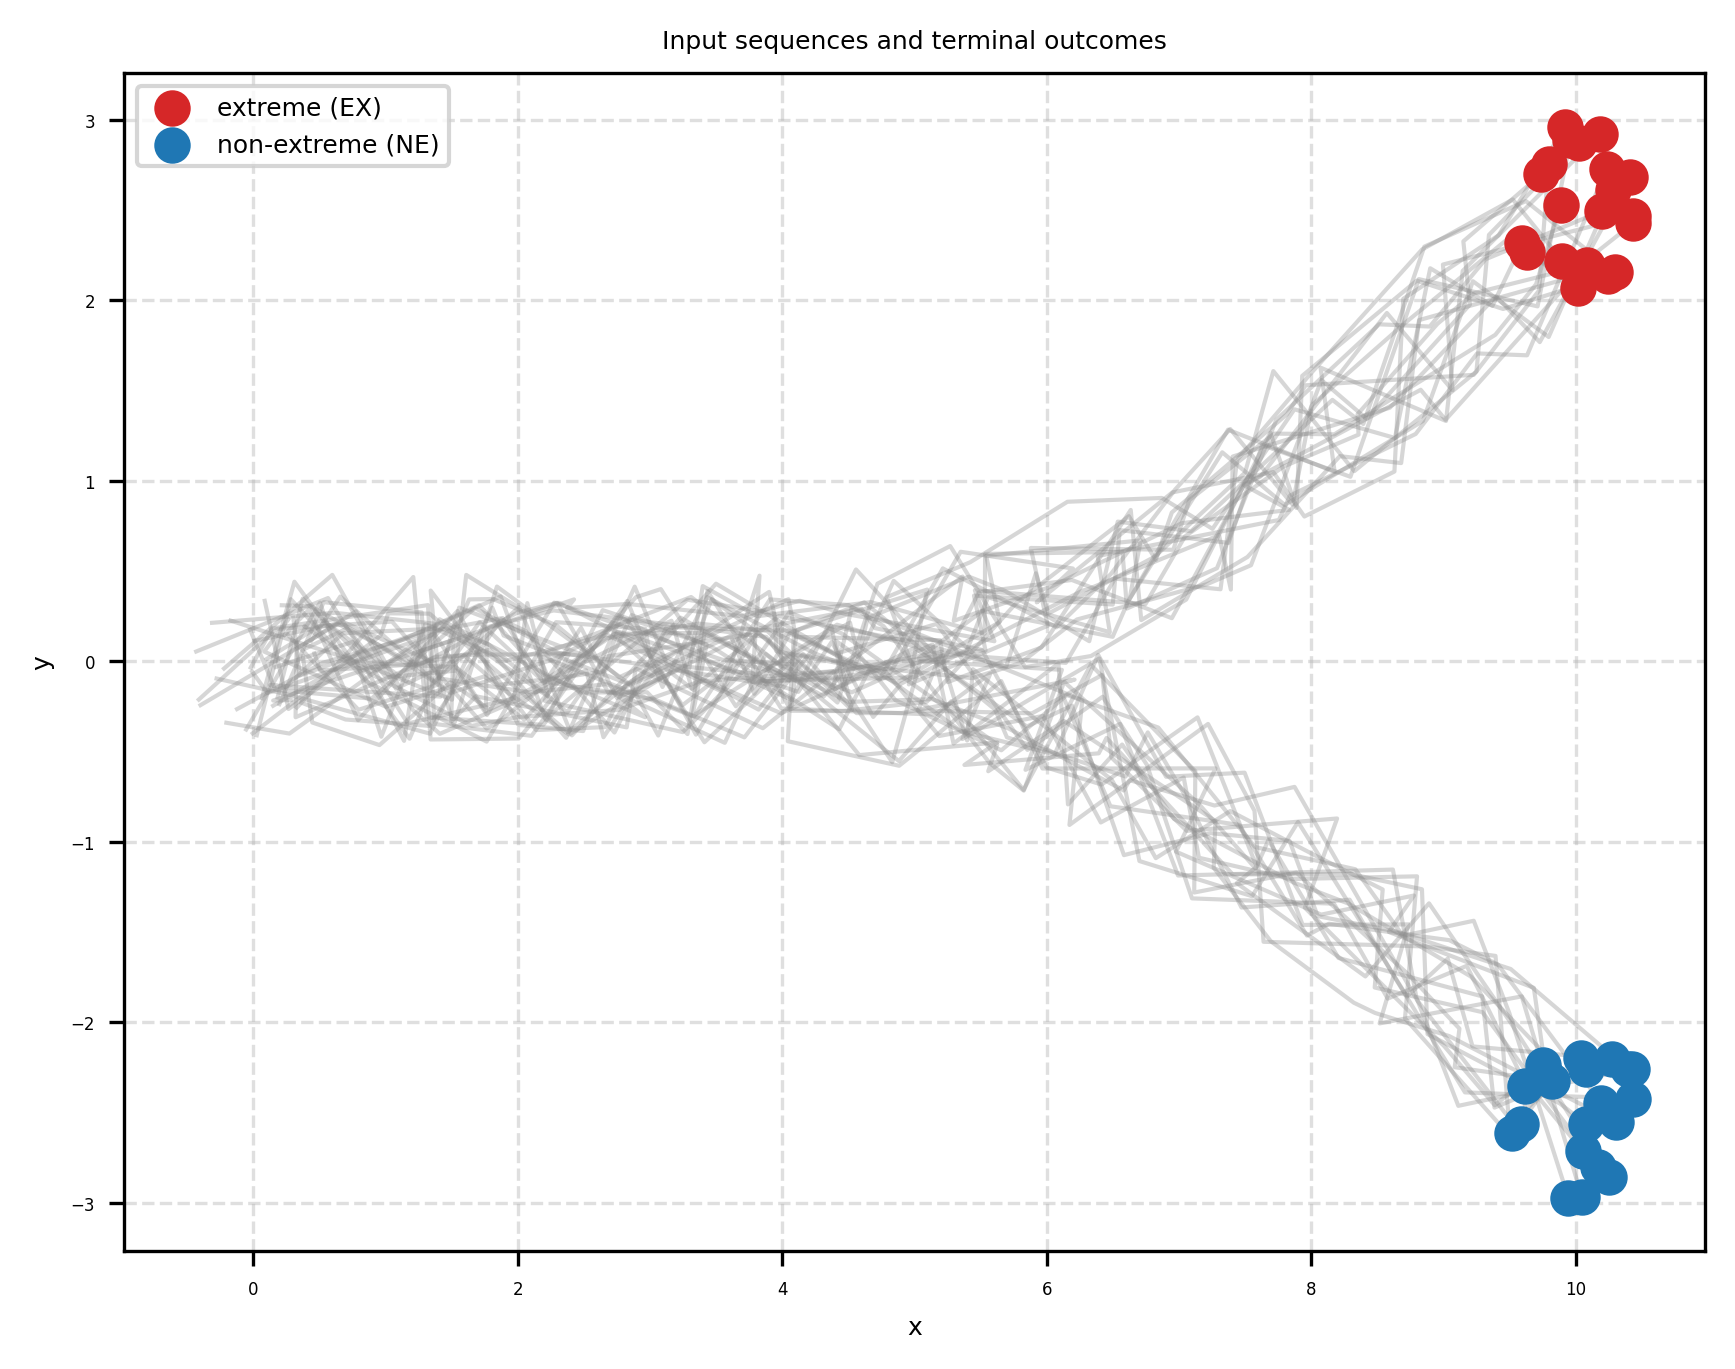

In [15]:
fig, ax = plt.subplots(figsize=(6.8, 5.1))
for sid in adata.obs['seq_id'].unique():
    idx = np.flatnonzero(adata.obs['seq_id'].to_numpy() == sid)
    ax.plot(adata.X[idx, 0], adata.X[idx, 1], '-', color='0.55', lw=1, alpha=0.35)
mask_ex = adata.obs['outcome'].to_numpy() == 'EX'
mask_ne = adata.obs['outcome'].to_numpy() == 'NE'
ax.scatter(adata.X[mask_ex, 0], adata.X[mask_ex, 1], s=60, color='tab:red', label='extreme (EX)', zorder=5)
ax.scatter(adata.X[mask_ne, 0], adata.X[mask_ne, 1], s=60, color='tab:blue', label='non-extreme (NE)', zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Input sequences and terminal outcomes')
ax.grid(ls='--', alpha=0.4)
ax.legend()
save_figure(fig, 'TwoBranch_Ensemble')
plt.show()


## Figure 1g: Minimum costs and commitment scores


Saved: figure_source/Simple/C_S_sum.png, figure_source/Simple/C_S_sum.svg


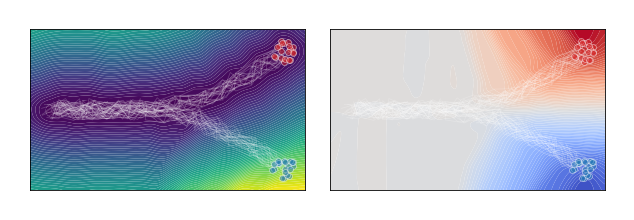

Saved: figure_source/Simple/C_S_max.png, figure_source/Simple/C_S_max.svg


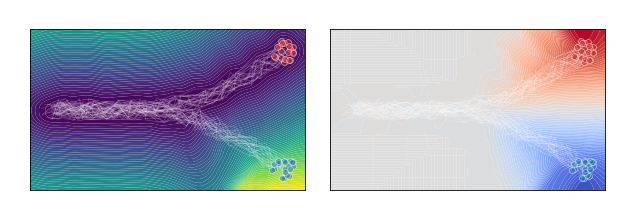

In [16]:
def _surface_for_fig1d(path_cost, time_value=None):
    """Return the nearest-time C-hat/S-hat surface.

    ``time_value`` is accepted only for backward compatibility with older
    plotting calls; query time is assigned separately at every state from its nearest ensemble point.
    """
    if path_cost == 'max':
        return (surface_inf, accuracy_inf, '\\infty')
    if path_cost == 'sum':
        return (surface_one, accuracy_one, '1')
    raise ValueError('FIG1D_PATH_COST must be "max" or "sum".')

def _overlay_ensemble(ax, *, time_value=None):
    """Overlay all trajectories because the field uses multiple time layers."""
    seq_values = adata.obs['seq_id'].to_numpy(dtype=int)
    time_values = adata.obs['time_idx'].to_numpy(dtype=int)
    X = np.asarray(adata.X, dtype=float)
    for sid in np.unique(seq_values):
        idx = np.flatnonzero(seq_values == sid)
        idx = idx[np.argsort(time_values[idx])]
        ax.plot(X[idx, 0], X[idx, 1], color='white', lw=0.2, alpha=0.2, zorder=3)
    terminal_ex = np.flatnonzero(adata.obs['outcome'].to_numpy() == 'EX')
    terminal_ne = np.flatnonzero(adata.obs['outcome'].to_numpy() == 'NE')
    ax.scatter(X[terminal_ex, 0], X[terminal_ex, 1], s=2, color='tab:red', zorder=5, alpha=0.5, linewidths=0.2, edgecolors='w')
    ax.scatter(X[terminal_ne, 0], X[terminal_ne, 1], s=2, color='tab:blue', zorder=5, alpha=0.5, linewidths=0.2, edgecolors='w')
    ax.set_aspect('equal')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

def plot_C_S(FIG1D_PATH_COST='max', FIG1D_COST_TARGET='EX', FIG1D_TIME_IDX=None, SAVE_FIG1D_LIKE=False, FIG1D_OUTPUT_STEM=Path('figures') / 'test_simple_Fig1d_like', smooth_sigma=DISPLAY_SMOOTH_SIGMA, display_upsample=DISPLAY_UPSAMPLE):
    """Plot display-smoothed C-hat/S-hat panels.

    Smoothing and dense cubic interpolation are applied only to plotting
    copies; ``surface_inf`` and ``surface_one`` retain the raw computed values.
    Use ``smooth_sigma=0`` and ``display_upsample=1`` for the raw-grid view.
    """
    surface_fig1d, accuracy_fig1d, p_tex = _surface_for_fig1d(FIG1D_PATH_COST, FIG1D_TIME_IDX)
    if FIG1D_COST_TARGET == 'EX':
        cost_field = surface_fig1d['cost_EX']
        cost_title = f'Minimum perturbation cost $\\widehat{{C}}_{{{p_tex},\\mathrm{{EX}}}}$'
    elif FIG1D_COST_TARGET == 'NE':
        cost_field = surface_fig1d['cost_NE']
        cost_title = f'Minimum perturbation cost $\\widehat{{C}}_{{{p_tex},\\mathrm{{NE}}}}$'
    else:
        raise ValueError('FIG1D_COST_TARGET must be "EX" or "NE".')
    score_field = surface_fig1d['score']
    finite_score = score_field[np.isfinite(score_field)]
    vabs = np.max(np.abs(finite_score)) if finite_score.size else 1.0
    if vabs == 0.0:
        vabs = 1.0
    X_cost, Y_cost, cost_field_plot = _smooth_regular_grid_for_display(surface_fig1d['X'], surface_fig1d['Y'], cost_field, sigma=smooth_sigma, upsample=display_upsample)
    X_score, Y_score, score_field_plot = _smooth_regular_grid_for_display(surface_fig1d['X'], surface_fig1d['Y'], score_field, sigma=smooth_sigma, upsample=display_upsample, lower=-vabs, upper=vabs)
    fig, axes = plt.subplots(1, 2, figsize=(2, 0.85), constrained_layout=True, dpi=300)
    ax_cost, ax_score = axes
    cost_im = ax_cost.contourf(X_cost, Y_cost, cost_field_plot, levels=64, cmap='viridis', antialiased=True)
    _overlay_ensemble(ax_cost, time_value=FIG1D_TIME_IDX)
    for spine in ax_cost.spines.values():
        spine.set_linewidth(0.2)
    score_im = ax_score.contourf(X_score, Y_score, score_field_plot, levels=np.linspace(-vabs, vabs, 81), cmap='coolwarm', vmin=-vabs, vmax=vabs, antialiased=True)
    _overlay_ensemble(ax_score, time_value=FIG1D_TIME_IDX)
    for spine in ax_score.spines.values():
        spine.set_linewidth(0.2)
    save_figure(fig, f'C_S_{FIG1D_PATH_COST}')
    plt.show()
plot_C_S(FIG1D_PATH_COST='sum', FIG1D_COST_TARGET='EX', FIG1D_TIME_IDX=None)
plot_C_S(FIG1D_PATH_COST='max', FIG1D_COST_TARGET='EX', FIG1D_TIME_IDX=None)


## Figure 1h: Prediction accuracy


Saved: figure_source/Simple/Prob.png, figure_source/Simple/Prob.svg


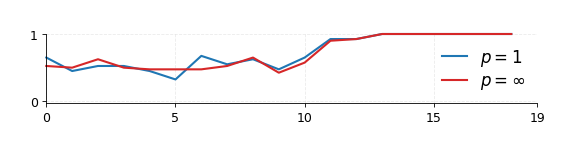

In [17]:
FIG1D_PATH_COST = 'sum'
FIG1D_COST_TARGET = 'EX'
FIG1D_TIME_IDX = None
SAVE_FIG1D_LIKE = False
FIG1D_OUTPUT_STEM = Path('figures') / 'test_simple_Fig1d_like'
_, accuracy_sum, _ = _surface_for_fig1d('sum', FIG1D_TIME_IDX)
_, accuracy_max, _ = _surface_for_fig1d('max', FIG1D_TIME_IDX)
fig, ax = plt.subplots(figsize=(1.8, 0.4), constrained_layout=True, dpi=300)
ax.plot(loso_time_values, accuracy_sum, color='tab:blue', lw=0.5, ms=0, clip_on=False, label='$p=1$')
ax.plot(loso_time_values, accuracy_max, color='tab:red', lw=0.5, ms=0, clip_on=False, label='$p=\\infty$')
ax.set_xlim(0, 19)
ax.set_ylim(-0.02, 1.0)
ax.grid(ls='--', alpha=0.25, lw=0.2)
ax.set_xticks([0, 5, 10, 15, 19])
ax.tick_params(axis='both', which='both', width=0.2, pad=1, length=1, labelsize=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(0.2)
ax.legend(frameon=False, fontsize=4, loc='lower right', handlelength=1.5, handleheight=0.5, labelspacing=0.2, borderpad=0.2)
save_figure(fig, f'Prob')
plt.show()


## Figure 1i: Norm-dependent optimal plans


Saved: figure_source/Simple/optimal_plans_demo.png, figure_source/Simple/optimal_plans_demo.svg


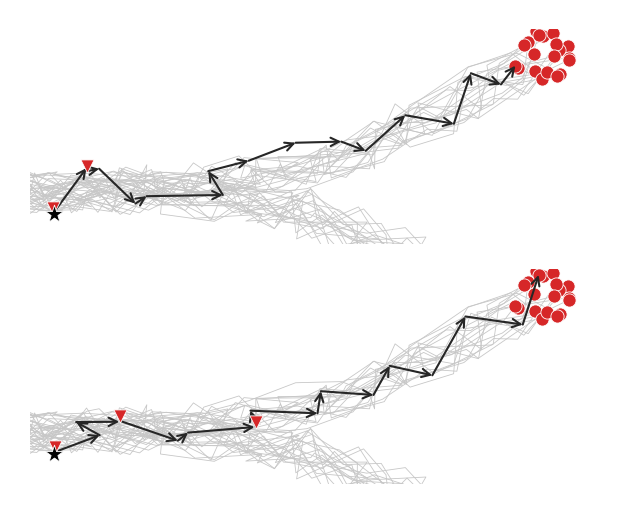

In [18]:
from matplotlib.lines import Line2D

def plot_same_dynamics_plan(ax, result, *, p_label):
    X_all = np.asarray(adata.X, dtype=float)
    seq_values = adata.obs['seq_id'].to_numpy(dtype=int)
    time_values = adata.obs['time_idx'].to_numpy(dtype=int)
    for sid in np.unique(seq_values):
        idx = np.flatnonzero(seq_values == sid)
        idx = idx[np.argsort(time_values[idx])]
        ax.plot(X_all[idx, 0], X_all[idx, 1], color='0.78', linewidth=0.2, alpha=1.0, zorder=1)
    same_time = np.flatnonzero(time_values == PLAN_DEMO_QUERY_TIME_IDX)
    terminal_ex = np.flatnonzero(adata.obs['cluster'].astype(str).to_numpy() == EX_CLUSTER_KEY)
    terminal_ne = np.flatnonzero(adata.obs['cluster'].astype(str).to_numpy() == NE_CLUSTER_KEY)
    ax.scatter(X_all[terminal_ex, 0], X_all[terminal_ex, 1], s=10, color='tab:red', edgecolor='white', linewidth=0.2, zorder=4)
    ax.scatter(X_all[terminal_ne, 0], X_all[terminal_ne, 1], s=3, color='tab:blue', edgecolor='white', linewidth=0.5, zorder=4)
    ax.scatter([x_plan_demo[0]], [x_plan_demo[1]], marker='*', s=20, color='black', edgecolor='white', linewidth=0.2, zorder=20)
    path = result.path_good
    control_number = 0
    for step in path.steps:
        p0 = x_plan_demo if step.source_index is None else X_all[int(step.source_index)]
        p1 = X_all[int(step.destination_index)]
        is_control = step.kind in {'entry', 'switch', 'graph'}
        if is_control and float(step.cost) <= 1e-10:
            continue
        if is_control:
            control_number += 1
            midpoint = 0.5 * (p0 + p1)
            source_time = PLAN_DEMO_QUERY_TIME_IDX if step.source_index is None else int(adata.obs.iloc[int(step.source_index)]['time_idx'])
            ax.scatter([p1[0]], [p1[1] + 0.1], marker='v', s=10, color='tab:red', edgecolor='white', linewidth=0.2, zorder=10)
        else:
            ax.annotate('', xy=p1, xytext=p0, arrowprops=dict(arrowstyle='->', color='0.15', linewidth=0.5, mutation_scale=5, shrinkA=0, shrinkB=0), zorder=7)
    controls = [float(step.cost) for step in nonzero_control_steps(path)]
    if result.path_cost == 'sum':
        cost_text = '$C_{1,\\mathrm{EX}}=\\sum_i\\varepsilon_i$' + f' = {result.epsilon_good:.3f}'
    else:
        cost_text = '$C_{\\infty,\\mathrm{EX}}=\\max_i\\varepsilon_i$' + f' = {result.epsilon_good:.3f}'
    ax.set_xlabel('state coordinate 1')
    ax.set_ylabel('state coordinate 2')
    ax.grid(ls=':', alpha=0.2)
    ax.set_xlim(2, 11)
    ax.set_ylim(-1, 3)
    ax.axis('off')
fig, axes = plt.subplots(2, 1, figsize=(2, 1.6), constrained_layout=True, sharex=True, sharey=True)
plot_same_dynamics_plan(axes[0], plan_demo_one, p_label='$p=1$: one larger perturbation')
plot_same_dynamics_plan(axes[1], plan_demo_inf, p_label='$p=\\infty$: relay of smaller perturbations')
legend_handles = [Line2D([0], [0], color='tab:red', linewidth=2.7, linestyle='--', marker='>', markevery=[1], label='perturbation / control'), Line2D([0], [0], color='0.15', linewidth=1.7, label='natural time evolution'), Line2D([0], [0], marker='*', color='none', markerfacecolor='black', markeredgecolor='white', markersize=11, label='query state x'), Line2D([0], [0], marker='o', color='none', markerfacecolor='tab:red', markersize=7, label='terminal EX')]
save_figure(fig, 'optimal_plans_demo')
plt.show()


## Supplementary Figure S1: Two-dimensional and three-dimensional landscapes


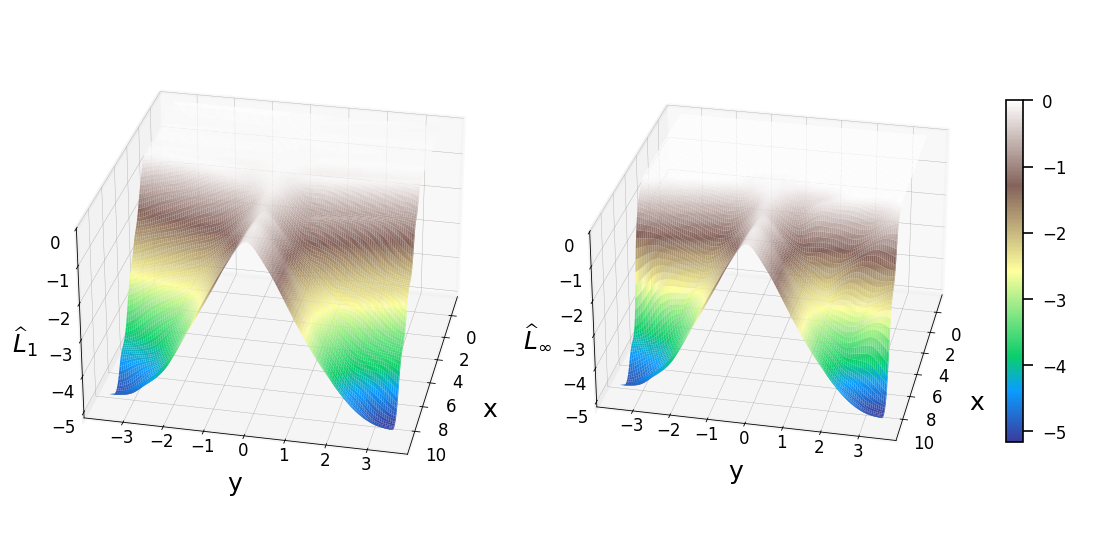

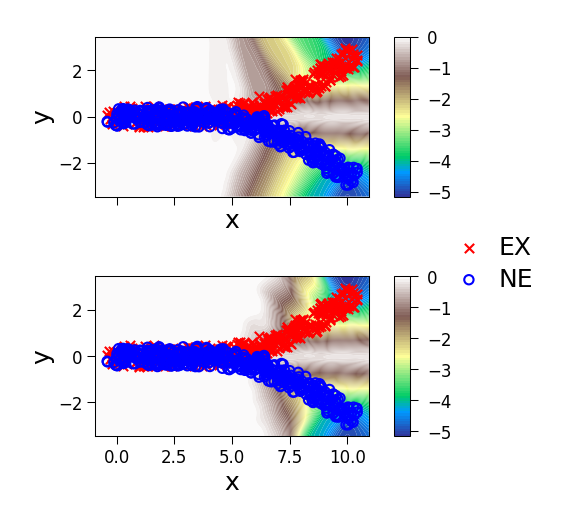

In [19]:
from mpl_toolkits.mplot3d import Axes3D

def _landscape_from_score_surface(surface, label):
    landscape = dict(surface)
    landscape['score'] = -np.abs(np.asarray(surface['score'], dtype=float))
    landscape['label'] = label
    return landscape
landscape_inf = _landscape_from_score_surface(surface_inf, '$\\widehat L_\\infty=-|\\widehat S_\\infty|$')
landscape_one = _landscape_from_score_surface(surface_one, '$\\widehat L_1=-|\\widehat S_1|$')

def _landscape_limit(*surfaces):
    finite_values = []
    for surface in surfaces:
        values = np.asarray(surface['score'], dtype=float)
        finite_values.extend(np.abs(values[np.isfinite(values)]).tolist())
    if not finite_values:
        return 1.0
    value = float(np.max(finite_values))
    return 1.0 if value == 0.0 else value

def colorbar_ticks(vabs, step=1):
    lower = -np.floor(vabs / step) * step
    return np.arange(lower, 0.0 + step / 2, step)

def plot_landscape_surface_3d(ax, surface, *, vabs, zlabel, smooth_sigma=DISPLAY_SMOOTH_SIGMA, display_upsample=DISPLAY_UPSAMPLE):
    """Draw a display-smoothed 3D landscape without modifying raw values."""
    Xg, Yg, Zg = _smooth_regular_grid_for_display(surface['X'], surface['Y'], surface['score'], sigma=smooth_sigma, upsample=display_upsample, lower=-vabs, upper=0.0)
    plotted = ax.plot_surface(Xg, Yg, Zg, cmap='terrain', vmin=-vabs, vmax=0.0, linewidth=0, edgecolor='none', antialiased=True, shade=True, rcount=min(180, Zg.shape[0]), ccount=min(180, Zg.shape[1]), alpha=0.96)
    ax.set_xlabel('x', labelpad=-10)
    ax.set_ylabel('y', labelpad=-13)
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel(zlabel, rotation=0, labelpad=-13)
    ax.set_box_aspect((1, 1, 0.65))
    ax.set_zlim(-vabs, 0.0)
    ax.view_init(elev=28, azim=12)
    ax.tick_params(axis='x', length=2.0, pad=-4)
    ax.tick_params(axis='y', length=2.0, pad=-7)
    ax.tick_params(axis='z', length=2.0, pad=-5)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis._axinfo['tick']['linewidth'] = {True: 0.2, False: 0.1}
        axis.line.set_linewidth(0.2)
        axis._axinfo['grid']['linewidth'] = 0.1
    return plotted

def plot_landscape_map(ax, surface, *, vabs, smooth_sigma=DISPLAY_SMOOTH_SIGMA, display_upsample=DISPLAY_UPSAMPLE, show_outcomes=True, show_legend=False, point_size=5.0):
    """Draw the smooth 2D landscape with optional EX/NE observations.

    EX observations are red crosses and NE observations are blue open circles.
    Because the nearest-time surface has no single query layer, every ensemble
    observation used by the surface is labelled by its trajectory's terminal
    outcome.  Smoothing remains display-only and does not move the points.
    """
    Xg, Yg, Zg = _smooth_regular_grid_for_display(surface['X'], surface['Y'], surface['score'], sigma=smooth_sigma, upsample=display_upsample, lower=-vabs, upper=0.0)
    image = ax.contourf(Xg, Yg, Zg, levels=np.linspace(-vabs, 0.0, 64), cmap='terrain', vmin=-vabs, vmax=0.0, antialiased=True)
    if show_outcomes:
        indices = np.asarray(surface.get('support_indices', surface.get('current_indices')), dtype=int)
        outcomes = _outcome_for_current_states(adata, indices)
        X_observed = np.asarray(adata.X[indices], dtype=float)
        ex_points = X_observed[outcomes == 'EX']
        ne_points = X_observed[outcomes == 'NE']
        if ex_points.size:
            ax.scatter(ex_points[:, 0], ex_points[:, 1], s=point_size, marker='x', color='red', linewidths=0.5, label='EX', zorder=5)
        if ne_points.size:
            ax.scatter(ne_points[:, 0], ne_points[:, 1], s=point_size, marker='o', facecolors='none', edgecolors='blue', linewidths=0.5, label='NE', zorder=5)
    ax.set_xlim(*surface['xlim'])
    ax.set_ylim(*surface['ylim'])
    ax.set_aspect('equal')
    ax.set_xlabel('x', labelpad=1)
    ax.set_ylabel('y', labelpad=1)
    ax.tick_params(axis='x', length=2.0, pad=1, width=0.25)
    ax.tick_params(axis='y', length=2.0, pad=1, width=0.25)
    for spine in ax.spines.values():
        spine.set_linewidth(0.25)
    if show_legend:
        ax.legend(frameon=False, fontsize=STYLE.tick_fs, loc='upper left', handletextpad=0.2)
    return image
vabs_landscape = _landscape_limit(landscape_one, landscape_inf)
fig = plt.figure(figsize=(3.8, 1.8), dpi=STYLE.dpi)
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 0.055], wspace=0.1)
ax1 = fig.add_subplot(gs[0, 0], projection='3d')
ax2 = fig.add_subplot(gs[0, 1], projection='3d')
s1 = plot_landscape_surface_3d(ax1, landscape_one, vabs=vabs_landscape, zlabel='$\\widehat L_1$')
plot_landscape_surface_3d(ax2, landscape_inf, vabs=vabs_landscape, zlabel='$\\widehat L_\\infty$')
cbar = fig.colorbar(s1, ax=ax2, fraction=0.05, pad=0.025, shrink=0.68, aspect=20, ticks=colorbar_ticks(vabs_landscape))
cbar.outline.set_linewidth(0.4)
cbar.ax.tick_params(width=0.4, length=2.5, pad=2)
fig.subplots_adjust(left=0.03, right=0.96, bottom=0.05, top=0.98, wspace=0.0)
if SAVE_SCORE_SURFACE_FIGURES:
    fig.savefig(SCORE_SURFACE_OUTPUT_DIR / 'Landscape_3D_nearest_time.png', dpi=300, bbox_inches='tight')
    fig.savefig(SCORE_SURFACE_OUTPUT_DIR / 'Landscape_3D_nearest_time.pdf', bbox_inches='tight')
plt.show()
fig, axes = plt.subplots(2, 1, figsize=(3.0, 1.8), dpi=STYLE.dpi, sharex=True)
fig.subplots_adjust(hspace=0.5)
im_one = plot_landscape_map(axes[0], landscape_one, vabs=vabs_landscape, show_outcomes=True)
im_inf = plot_landscape_map(axes[1], landscape_inf, vabs=vabs_landscape, show_outcomes=True)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(0.83, 0.5), ncol=1, frameon=False, fontsize=STYLE.tick_fs, handletextpad=0.2, labelspacing=0.3)
fig.subplots_adjust(left=0.08, right=0.86, bottom=0.18, top=0.92, wspace=0.1)
fig.canvas.draw()
for ax, image in zip(axes, (im_one, im_inf)):
    position = ax.get_position()
    cax = fig.add_axes([0.65, position.y0, 0.018, position.height])
    cbar = fig.colorbar(image, cax=cax, ticks=colorbar_ticks(vabs_landscape))
    cbar.outline.set_linewidth(0.25)
    cbar.ax.tick_params(width=0.25, length=2.0, pad=2)
if SAVE_SCORE_SURFACE_FIGURES:
    fig.savefig(SCORE_SURFACE_OUTPUT_DIR / 'Landscape_surface_nearest_time.png', dpi=300, bbox_inches='tight')
    fig.savefig(SCORE_SURFACE_OUTPUT_DIR / 'Landscape_surface_nearest_time.pdf', bbox_inches='tight')
plt.show()
